In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import DiadFit as pf
pf.__version__

'1.0.22'

In [2]:
def correct_power(df):
    correction_factors = {
        5: 0.80,
        20: 0.79,
        40: 0.77,
        50: 0.62,
        100: 0.43
    }
    
    df['Power_corr'] = df.apply(
        lambda row: row['power (mW)'] * correction_factors.get(row['Mag (X)'], np.nan),
        axis=1
    )
    
    return df

## Lets load in all the power series. 

In [3]:


df= pd.read_excel(r'C:\Users\penny\Box\Berkeley_new\Raman\Raman technical paper\Supporting_Info\Supporting_information_Revision.xlsx',
                          sheet_name='power_series')

# Convert power
df=correct_power(df)

df_16=df.loc[df['filename'].str.contains('FG04-A11-16')]
df_9=df.loc[df['filename'].str.contains('FG04-A11-9')]
df_21=df.loc[df['filename'].str.contains('Ulu')]
# Filt out 49 mW with a big cosmic ray so bad peak fit
df_21=df_21.loc[df_21['power (mW)']<49]

In [4]:
df_21=df_21.loc[df_21['σ Density g/cm3']>0]

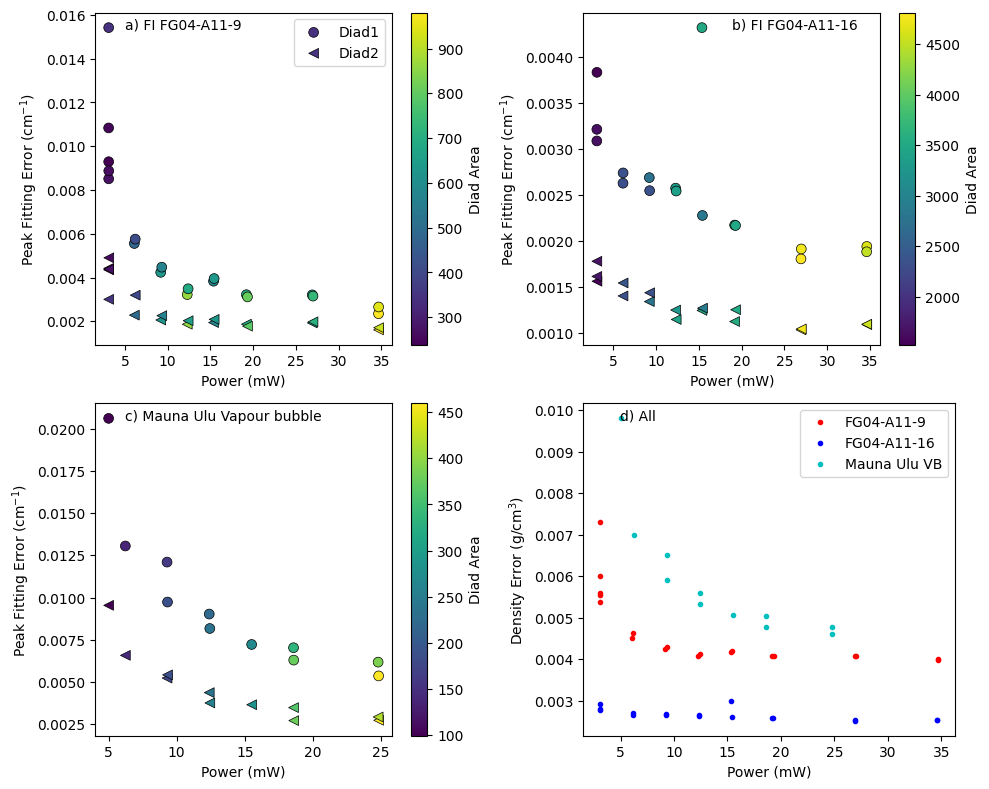

In [5]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10,8))

s=ax1.scatter(x=df_9['Power_corr'],
          y=df_9['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_9['Diad1_Voigt_Area'], cmap='viridis', label='Diad1')

s=ax1.scatter(x=df_9['Power_corr'],
          y=df_9['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_9['Diad2_Voigt_Area'], cmap='viridis',  label='Diad2')
fig.colorbar(s, ax=ax1, label='Diad Area')
ax1.set_xlabel('Power (mW)')
ax1.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax1.annotate("a) FI FG04-A11-9 ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)
ax1.legend()

##########################
s=ax2.scatter(x=df_16['Power_corr'],
          y=df_16['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_16['Diad1_Voigt_Area'], cmap='viridis')

s=ax2.scatter(x=df_16['Power_corr'],
          y=df_16['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_16['Diad2_Voigt_Area'], cmap='viridis')
fig.colorbar(s, ax=ax2, label='Diad Area')
ax2.set_xlabel('Power (mW)')
ax2.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax2.annotate("b) FI FG04-A11-16 ", xy=(0.5, 0.95), xycoords="axes fraction", fontsize=10)

##################3

s=ax3.scatter(x=df_21['Power_corr'],
          y=df_21['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_21['Diad1_Voigt_Area'], cmap='viridis')

s=ax3.scatter(x=df_21['Power_corr'],
          y=df_21['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_21['Diad2_Voigt_Area'], cmap='viridis')
fig.colorbar(s, ax=ax3, label='Diad Area')
ax3.set_xlabel('Power (mW)')
ax3.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax3.annotate("c) Mauna Ulu Vapour bubble ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)

## Lets show them all for context

# ax4.plot(df_9['power (mW)'], 100*df_9['σ Density g/cm3']/df_9['Density g/cm3'].iloc[0], '.r')
# ax4.plot(df_21['power (mW)'], 100*df_21['σ Density g/cm3']/df_21['Density g/cm3'].iloc[0], '.b')
# ax4.plot(df_16['power (mW)'], 100*df_16['σ Density g/cm3']/df_16['Density g/cm3'].iloc[0], '.c')

ax4.plot(df_9['Power_corr'],df_9['σ Density g/cm3'], '.r', label='FG04-A11-9')
ax4.plot(df_16['Power_corr'], df_16['σ Density g/cm3'], '.b', label='FG04-A11-16')
ax4.plot(df_21['Power_corr'], df_21['σ Density g/cm3'], '.c', label='Mauna Ulu VB')
ax4.legend()

ax4.annotate("d) All", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)


fig.tight_layout()
ax4.set_xlabel('Power (mW)')
ax4.set_ylabel('Density Error (g/cm$^{3}$)')
fig.savefig('Errors_laser_power.png', dpi=200)

In [6]:
df_9

,Unnamed: 0,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,Peak_Area_Carb,Peak_Height_Carb,Model_name_y,Carb_Diad_Ratio,SO2_Diad_Ratio,SO2_mol_ratio,Model_name,focus_testing,offset,Power_corr
12,0,FG04-A11-9-4mW-1,0.120687,0.007298,0.006213,0.003829,103.054836,0.015681,0.000536,0.015707,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.09771
13,1,FG04-A11-9-4mW-1re,0.114888,0.005584,0.004073,0.003820,103.040200,0.010279,0.000534,0.010288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.09771
14,2,FG04-A11-9-4mW-1re2,0.123675,0.006005,0.004621,0.003834,103.062377,0.011662,0.000533,0.011676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.09078
15,3,FG04-A11-9-8mW-1,0.116594,0.004505,0.002384,0.003822,103.044508,0.006016,0.000530,0.006006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.09763
16,4,FG04-A11-9-12mW-1,0.109208,0.004249,0.001875,0.003813,103.025866,0.004731,0.000528,0.004712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.18225
17,5,FG04-A11-9-16mW-1,0.106470,0.004090,0.001486,0.003810,103.018956,0.003751,0.000526,0.003723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.28612
18,6,FG04-A11-9-20mW-1,0.114547,0.004185,0.001711,0.003820,103.039340,0.004319,0.000524,0.004297,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.35842
19,7,FG04-A11-9-25mW-1,0.103404,0.004087,0.001485,0.003807,103.011219,0.003748,0.000524,0.003720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.20149
20,8,FG04-A11-9-35mW-1,0.104868,0.004091,0.001494,0.003809,103.014912,0.003769,0.000523,0.003741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.90611
21,9,FG04-A11-9-45mW-1,0.102483,0.003975,0.001144,0.003807,103.008894,0.002886,0.000522,0.002845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.65770


In [7]:
ax1.plot(df['power (mW)'], df['Diad2_cent_err'], '.b')

ax2.plot(df['power (mW)'], df['Diad1_Voigt_Area'], '.r')

In [8]:
df_9.columns

Index(['Unnamed: 0', 'filename', 'Density g/cm3', 'σ Density g/cm3',
       'σ Density g/cm3 (from Ne+peakfit)',
       'σ Density g/cm3 (from densimeter)', 'Corrected_Splitting',
       'Corrected_Splitting_σ', 'Corrected_Splitting_σ_Ne',
       'Corrected_Splitting_σ_peak_fit',
       ...
       'Peak_Area_Carb', 'Peak_Height_Carb', 'Model_name_y', 'Carb_Diad_Ratio',
       'SO2_Diad_Ratio', 'SO2_mol_ratio', 'Model_name', 'focus_testing',
       'offset', 'Power_corr'],
      dtype='object', length=106)

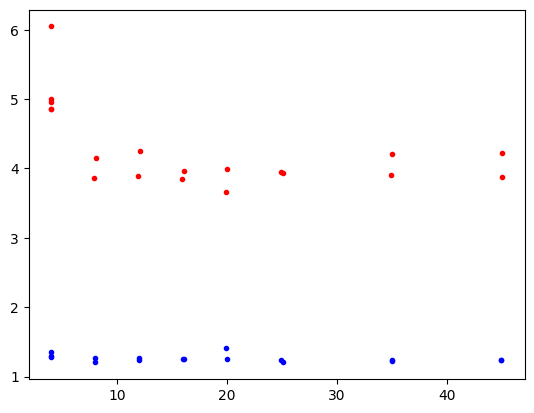

In [9]:
plt.plot(df_9['power (mW)'], 100*df_9['σ Density g/cm3']/df_9['Density g/cm3'], '.r')
plt.plot(df_16['power (mW)'], 100*df_16['σ Density g/cm3']/df_16['Density g/cm3'], '.b')

[]

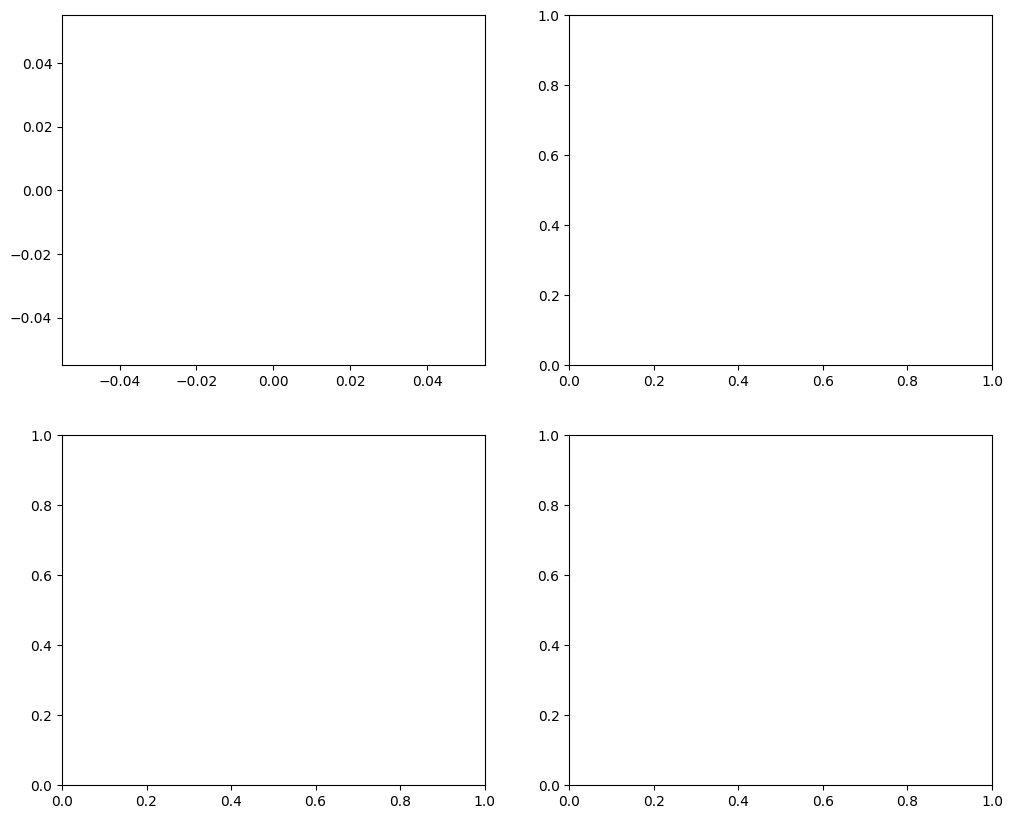

In [10]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2,2, figsize = (12,10))

ax0.plot()